# SC05 — Uncertainty-Aware Design Maps for Chemistry-Driven Strength Control

> **Predictive models become decision tools only when uncertainty is made explicit.**

This notebook translates a validated chemistry-only UTS model into conservative, 
human-readable design maps that support robust engineering decisions.

---

**Study case context:** This completes the portfolio arc (SC01 → SC02 → SC03 → SC04 → SC05)

## Notebook Setup

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Portfolio Analytics Toolkit
from portfolio_analytics_toolkit.io import load_public_dataset
from portfolio_analytics_toolkit.cv import build_oof_predictions, metrics_by_fold
from portfolio_analytics_toolkit.plots import plot_hexbin_feature_domain, plot_oof_residual_quantiles
from portfolio_analytics_toolkit.plots.surfaces import (
    plot_mean_surface,
    plot_lower_bound_surface,
    plot_risk_zone_map,
    plot_model_comparison_surfaces,
    plot_risk_zone_surface,
    plot_robust_region_map
)
from portfolio_analytics_toolkit.validation.grain_check import (
    validate_grain,
    report_grain_check,
    profile_domain,
    report_domain_stats,
    check_missing,
    report_missing
)
from portfolio_analytics_toolkit.plots.bands import plot_uncertainty_band
from portfolio_analytics_toolkit.uncertainty import calculate_uncertainty_margin, build_robust_region_mask
from portfolio_analytics_toolkit.grids import build_2d_prediction_grid
from portfolio_analytics_toolkit.style import set_matplotlib_style

set_matplotlib_style('ggplot')

In [16]:

# ============================================
# CONSTANTS & REPRODUCIBILITY
# ============================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Analytical configuration
ALLOY_SYSTEM = ['3105']
FEATURE_COLS = ['mn', 'mg']
TARGET_COL = 'uts_mpa'
GROUP_COL = 'heat_num'

# Validation configuration
N_SPLITS = 5
COVERAGE_ALPHA = 0.10  # 90% coverage target

# Model configuration
ALPHA = 1.0  # Ridge regularization

# Map configuration
TARGET_UTS = 120  # Example target UTS in MPa
PERCENTILE_BOUNDS = (0.05, 0.95)
GRID_POINTS = 200

print(f'✓ Configuration loaded')
print(f'  Features (frozen): {FEATURE_COLS}')
print(f'  Validation: {N_SPLITS}-fold GroupKFold by {GROUP_COL}')
print(f'  Random state: {RANDOM_STATE}')

✓ Configuration loaded
  Features (frozen): ['mn', 'mg']
  Validation: 5-fold GroupKFold by heat_num
  Random state: 42


## 0. Executive Framing & Scope

Study Case 5 (SC05) extends the chemistry-only modeling framework established in SC02–SC04 by translating predictive uncertainty into explicit, decision-oriented design guidance.

Rather than focusing on point prediction accuracy, this study constructs uncertainty-aware design maps that express achievable strength behavior as bounded regions within the observed chemistry domain.

The objective of SC05 is not to improve model performance, but to enable defensible early-stage engineering decisions under quantified uncertainty. The focus is not on maximizing metrics, but on producing human-readable maps that support robust engineering decisions under an explicit uncertainty margin.

In [2]:
# ============================================
# DATA LOADING
# ============================================

required_cols = ['heat_num', 'uts_mpa', 'mn', 'mg']

df = load_public_dataset(
    dataset_id_or_path='sc05',
    csv_name='v_models_analysis_o.csv'
)

df_model = df[required_cols].copy()

print(f'✓ Data loaded: {len(df_model)} rows, {df_model[GROUP_COL].nunique()} unique {GROUP_COL}s')

✓ Data loaded: 2294 rows, 2294 unique heat_nums


In [3]:
# ============================================
# DATA INTEGRITY VALIDATION
# ============================================

# 1. GRAIN CHECK
grain_check = validate_grain(df_model, grain_col=GROUP_COL, expected_rows_per_unit=1)
report_grain_check(grain_check)

# 2. DATA DOMAIN
domain_stats = profile_domain(df_model, FEATURE_COLS + [TARGET_COL])
report_domain_stats(domain_stats)

# 3. MISSING DATA
missing_result = check_missing(df_model, FEATURE_COLS + [TARGET_COL])
report_missing(missing_result)

# Extract for analysis
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]
groups = df_model[GROUP_COL]

print('\n✓ READY FOR ANALYSIS')



✓ GRAIN VERIFICATION
  Total rows: 2294
  Total heat_nums: 2294
  Rows per heat_num: 1
  Leakage risk: NONE
            min      p05      p50      p95      max
mn        0.295    0.334    0.441    0.527    0.699
mg        0.200    0.218    0.432    0.591    0.776
uts_mpa  99.000  111.000  122.000  134.000  144.000

✓ MISSING DATA CHECK
  ✓ mn             :    0 missing ( 0.00%)
  ✓ mg             :    0 missing ( 0.00%)
  ✓ uts_mpa        :    0 missing ( 0.00%)

✓ READY FOR ANALYSIS

✓ READY FOR ANALYSIS


## 1. Why This Study Case Exists

Previous study cases demonstrated that bulk chemistry provides a stable, interpretable signal for heat-level UTS estimation, while also revealing a persistent and irreducible error structure.

In practice, engineering decisions are not made using expected values alone. They require an explicit understanding of risk, particularly the likelihood of falling below minimum strength thresholds.

SC05 exists to convert residual behavior and tail risk—previously treated as diagnostics—into explicit decision surfaces usable for design reasoning.

## 2. Conceptual Shift: From Prediction to Design Under Uncertainty

The analytical focus of SC05 shifts from estimating expected strength values to characterizing conditional uncertainty within the chemistry domain.

Instead of asking:

**"What UTS does this chemistry predict?"**

this study addresses:

**"What strength can be guaranteed, with known confidence, for this chemistry?"**

This reframing aligns model outputs with how internal standards and design margins are defined in engineering practice.

This study explicitly contrasts two common but fundamentally different approaches to engineering decisions: nominal target compliance versus uncertainty-aware robust design.


## 3. Analytical Unit, Assumptions, and Non-Goals

All analysis is performed at heat level, consistent with prior study cases and downstream decision granularity.

### Assumptions
- Bulk chemistry acts as a first-order constraint on achievable UTS
- Out-of-fold residuals represent realistic generalization error
- Uncertainty reflects both model limitations and unmodeled process effects

### Non-Goals
- Within-heat variability is not modeled
- No causal interpretation is assumed
- Extrapolation beyond the observed chemistry domain is explicitly unsupported

## 4. Data Domain and Validity Envelope

Uncertainty-aware design maps are constructed strictly within the observed chemistry domain.

The design maps are restricted to the p05–p95 chemistry window to avoid extrapolation.

Density-based support constraints are intentionally left as future work and are not enforced in this notebook version.

This constraint ensures that design guidance remains grounded in empirical evidence rather than extrapolation.

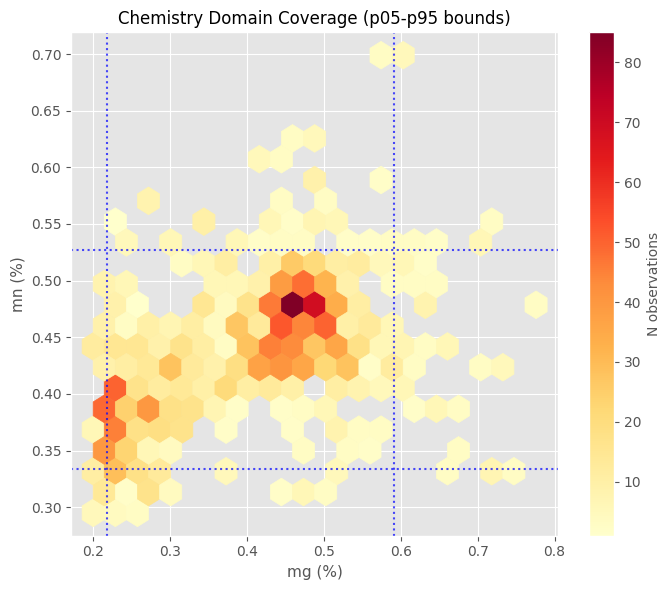

✓ Figure 2: Domain coverage saved


In [4]:
# Figure 2 — Chemistry Domain Coverage (p05-p95 bounds)
fig, ax = plot_hexbin_feature_domain(df_model, ['mg', 'mn'])
plt.show()
print('✓ Figure 2: Domain coverage saved')

## 5. From Residuals to Quantile-Based Guarantees

Rather than summarizing performance using average error metrics, SC05 leverages the empirical distribution of out-of-fold residuals to construct quantile-based strength guarantees.

High-percentile error behavior (p90) is emphasized, as these deviations are more relevant for non-conformance risk than central tendency metrics.

Quantiles are interpreted as risk-aware bounds, not probabilistic forecasts.

### Definition of the uncertainty margin

The uncertainty margin **q** is defined as the empirical **p(1−α)** quantile of the
absolute out-of-fold (OOF) residuals.

For this study:

- **α = 0.10**
- **q = p90(|residual|)**

This choice targets approximately **90% empirical OOF coverage** and defines a
**p90-safe conservative margin** for subsequent design decisions.


In [5]:
# ============================================
# MODELS DEFINITION & OOF PREDICTIONS
# ============================================

# Define models
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=ALPHA, random_state=RANDOM_STATE))
])

poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=ALPHA, random_state=RANDOM_STATE))
])

MODELS = {'ridge': ridge, 'polynomial': poly}

# Generate OOF predictions
oof_df = build_oof_predictions(
    df=df_model,
    models=MODELS,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    group_col=GROUP_COL,
    n_splits=N_SPLITS
)

print(f'✓ OOF predictions generated: {len(oof_df)} records')

✓ OOF predictions generated: 4588 records


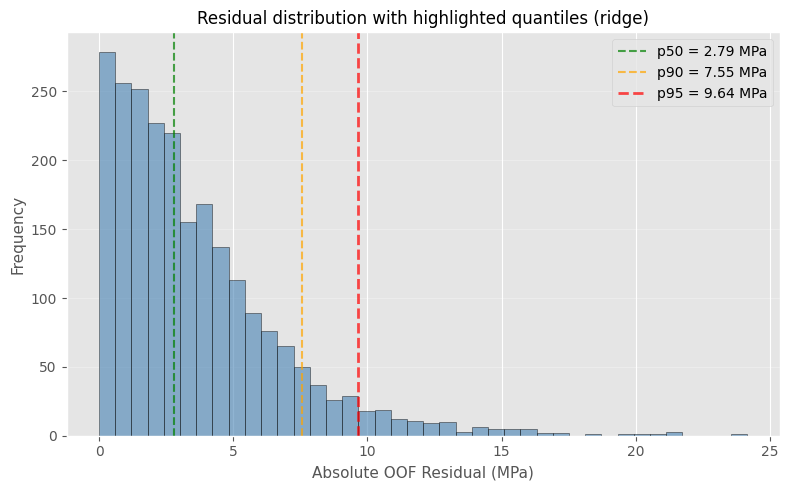

✓ Figure 3: Residual distribution saved


In [6]:
# Figure 3 — Residual Distribution with Highlighted Quantiles
fig, ax = plot_oof_residual_quantiles(
    oof_df,
    model_id='ridge',
    percentiles=(50, 90, 95)
)
plt.show()
print('✓ Figure 3: Residual distribution saved')

## 6. Construction of Uncertainty-Aware Design Maps

### From model equations to human-centered design tools

A common outcome of regression-based models is an explicit mathematical formulation, often summarized as a set of coefficients or an equation.

While this representation is sufficient in academic contexts, it rapidly loses practical interpretability as models become multivariate or non-linear. This effect is further amplified when features are standardized or normalized, as coefficient magnitudes no longer correspond directly to physical quantities.

For design purposes, the validated chemistry-only model is treated as a constraint generator rather than as an equation to be interpreted.

### Chemistry Design Maps

Design maps are constructed by evaluating predicted strength and associated uncertainty across the chemistry space.

Each location within the map represents:
- an expected strength level,
- a bounded uncertainty envelope,
- and an implied risk relative to a defined strength threshold.

These maps do not identify optimal compositions; they delineate where conservative design is defensible.

**Map domain (data-supported window).**

Maps are generated over a conservative chemistry window (p05–p95) to minimize extrapolation artifacts and keep interpretation grounded in observed data.

In [ ]:
# ============================================
# DESIGN MAP GENERATION
# ============================================

# Build prediction grid
grid_df, MG, MN, bounds = build_2d_prediction_grid(
    df_model,
    feature_cols=FEATURE_COLS,
    percentile_bounds=PERCENTILE_BOUNDS,
    grid_points=GRID_POINTS
)

print(f'✓ Prediction grid created: {len(grid_df)} points')
print(f'  Domain: Mg [{bounds["x"][0]:.3f}, {bounds["x"][1]:.3f}]')
print(f'          Mn [{bounds["y"][0]:.3f}, {bounds["y"][1]:.3f}]')

✓ Prediction grid created: 40000 points
  Domain: Mg [0.334, 0.527]
          Mn [0.218, 0.591]

✓ Uncertainty margins calculated
  Ridge: q = 7.55 MPa
  Polynomial: q = 7.45 MPa
✓ Maps generated and robust regions computed


In [20]:
# ============================================
# MODEL TRAINING AND PREDICTIONS
# ============================================

# Train final models on full data
m_ridge_final = clone(MODELS['ridge']).fit(X, y)
m_poly_final = clone(MODELS['polynomial']).fit(X, y)

# Generate predictions
yhat_ridge = m_ridge_final.predict(grid_df).reshape(MG.shape)
yhat_poly = m_poly_final.predict(grid_df).reshape(MN.shape)

# Calculate uncertainty margins
q_ridge = calculate_uncertainty_margin(oof_df[oof_df['model_id'] == 'ridge'], coverage_alpha=COVERAGE_ALPHA)
q_poly = calculate_uncertainty_margin(oof_df[oof_df['model_id'] == 'polynomial'], coverage_alpha=COVERAGE_ALPHA)

print(f'\n✓ Uncertainty margins calculated')
print(f'  Ridge: q = {q_ridge:.2f} MPa')
print(f'  Polynomial: q = {q_poly:.2f} MPa')

# Lower-bound surfaces
y_lower_ridge = yhat_ridge - q_ridge
y_lower_poly = yhat_poly - q_poly

# Robust region masks
robust_mask_ridge = build_robust_region_mask(yhat_ridge, q_ridge, TARGET_UTS)
robust_mask_poly = build_robust_region_mask(yhat_poly, q_poly, TARGET_UTS)

print(f'✓ Map spaces generated and robust regions computed')


✓ Uncertainty margins calculated
  Ridge: q = 7.55 MPa
  Polynomial: q = 7.45 MPa
✓ Map spaces generated and robust regions computed


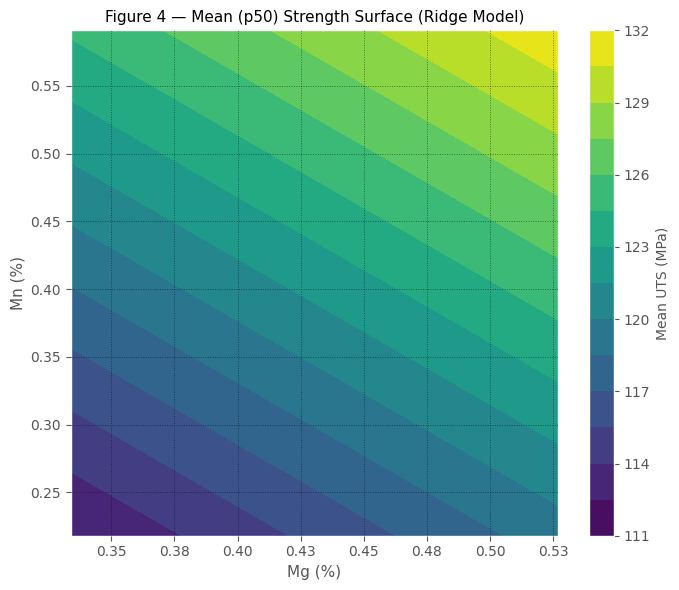

✓ Figure 4: Mean surface saved


In [8]:
# Figure 4 — Mean (p50) Strength Surface
fig, ax = plot_mean_surface(
    MG, MN, yhat_ridge,
    levels_val=12,
    x_label='Mg (%)',
    y_label='Mn (%)',
    cbar_label='Mean UTS (MPa)',
    title='Figure 4 — Mean (p50) Strength Surface (Ridge Model)',
    show_grid=True
)
plt.show()
print('✓ Figure 4: Mean surface saved')

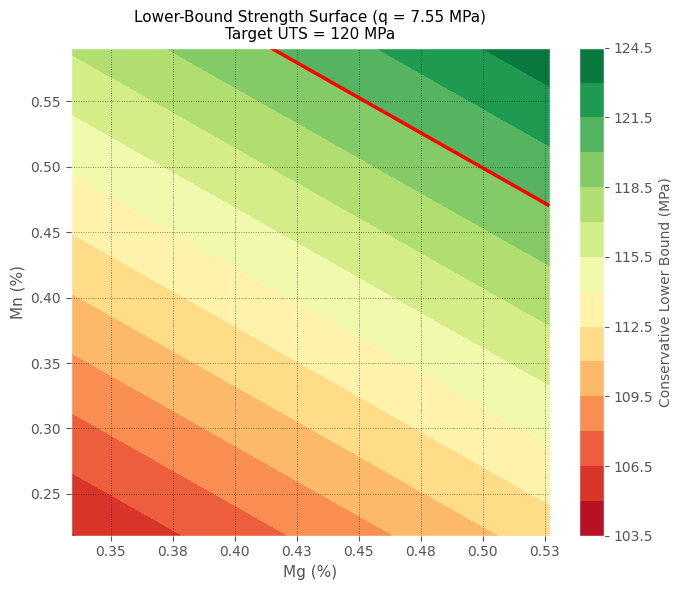

✓ Figure 5: Lower-bound surface (HERO) saved


In [17]:
# Figure 5 — Lower-Bound (p90-Safe) Strength Surface (THE HERO FIGURE)
fig, ax = plot_lower_bound_surface(
    MG, MN, y_lower_ridge,
    target_value=TARGET_UTS,
    uncertainty_margin=q_ridge,
    x_label='Mg (%)',
    y_label='Mn (%)',
    show_grid=True
)
plt.show()
print('✓ Figure 5: Lower-bound surface (HERO) saved')

## 7. Risk Zoning and Engineering Interpretation

To support practical use, the chemistry domain is segmented into qualitative risk zones based on quantile-based strength guarantees.

**Risk zones are defined numerically as:**
- **SAFE:** ŷ_lower(x) ≥ T (target)
- **CAUTION:** T - q/2 ≤ ŷ_lower(x) < T
- **RISK:** ŷ_lower(x) < T - q/2

This zoning enables comparison of chemistries based on risk profile, not expected performance.

The intermediate buffer **q/2** is a policy-driven engineering margin used to distinguish nominally acceptable regions from operationally robust ones.

It is not a probabilistic statement by itself, but a tunable design parameter that can be adjusted based on failure cost, rework risk, or customer sensitivity.


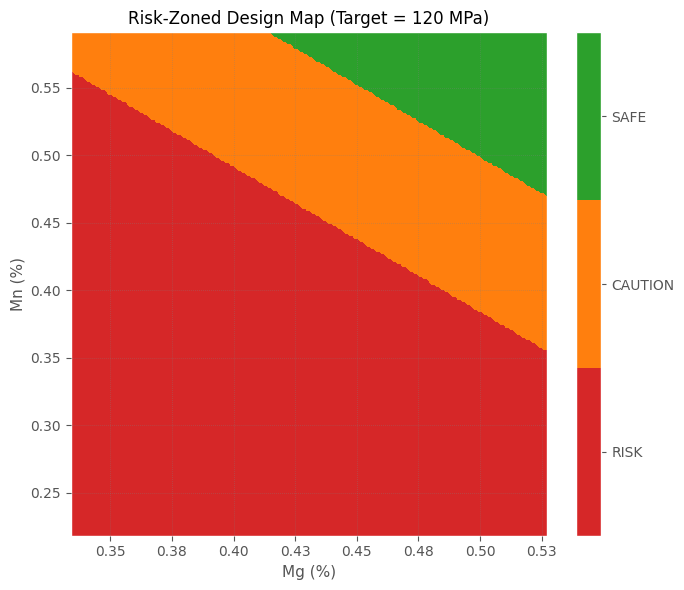

✓ Figure 6: Risk-zoned map saved


In [10]:
# Figure 6 — Risk-Zoned Design Map

# Define risk zones
q_half = q_ridge / 2
risk_zones = np.zeros_like(y_lower_ridge)
risk_zones[y_lower_ridge >= TARGET_UTS] = 2  # SAFE
risk_zones[(y_lower_ridge >= TARGET_UTS - q_half) & (y_lower_ridge < TARGET_UTS)] = 1  # CAUTION
risk_zones[y_lower_ridge < TARGET_UTS - q_half] = 0  # RISK

fig, ax = plot_risk_zone_map(
    MG, MN, risk_zones,
    target_value=TARGET_UTS,
    x_label='Mg (%)',
    y_label='Mn (%)',
    show_grid=True
)
plt.show()
print('✓ Figure 6: Risk-zoned map saved')

## 8. Traditional Chemistry Targets vs. Uncertainty-Aware Design


Uncertainty-aware design maps are contrasted with traditional chemistry targets defined using nominal or median strength values.

**Clarification:** 

Traditional targets are typically defined at the median (p50) strength level, without explicit uncertainty consideration.

This comparison highlights cases where conventional targets fall within high-risk regions once uncertainty is considered.

The analysis demonstrates that target compliance does not imply robustness.

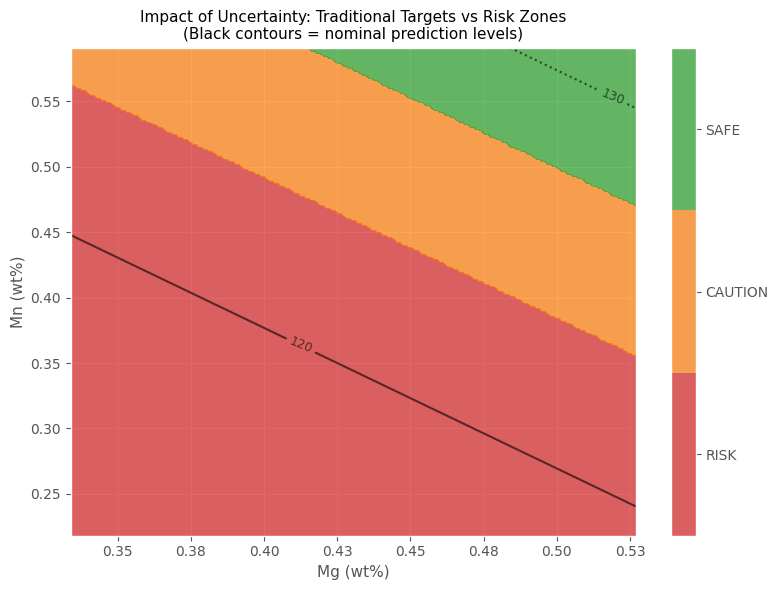

✓ Figure 7: Risk zones with overlay saved


In [11]:
# Figure 7 — Impact of Uncertainty: Traditional Targets vs Risk Zones
fig, ax = plot_risk_zone_surface(
    MG, MN, risk_zones,
    nominal_surface=yhat_ridge,
    target_value=TARGET_UTS,
    x_label='Mg (wt%)',
    y_label='Mn (wt%)',
    figsize=(8, 6)
)
plt.show()
print('✓ Figure 7: Risk zones with overlay saved')

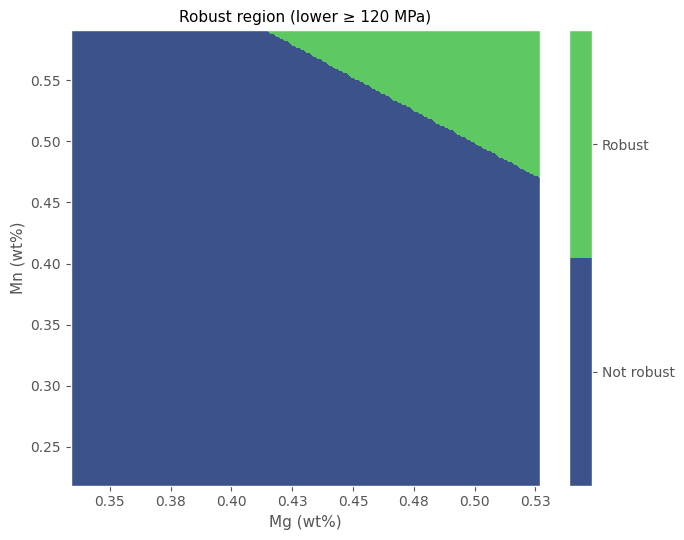

✓ Figure 8: Robust region map saved


In [12]:
# Figure 8 — Robust Region (Binary Decision Map)
fig, ax = plot_robust_region_map(
    MG, MN, robust_mask_ridge,
    target_value=TARGET_UTS,
    x_label='Mg (wt%)',
    y_label='Mn (wt%)',
)
plt.show()
print('✓ Figure 8: Robust region map saved')

The robust region identifies chemistry combinations for which the conservative
lower bound remains above the target under a p90-safe uncertainty margin.


### How these maps are used in practice

The design maps presented in this study support an inverse-design workflow:

1. A target UTS requirement is defined based on engineering or specification constraints.
2. A conservative uncertainty margin is applied to account for model error.
3. Chemistry regions where the lower-bound prediction satisfies the target are identified.
4. Robust chemistry windows are selected based on stability rather than nominal optimum.

The resulting robust-region maps provide a direct go / no-go decision rule for chemistry selection under uncertainty.

This workflow allows engineers to move from a performance requirement to a feasible and defensible chemistry space without manipulating model equations or coefficients.

### 8.1 Model Choice for Design Maps

**Why ridge for design tooling.**  

Even when average metrics are similar across simple models, the map geometry can differ meaningfully. We compare ridge vs. a second-order polynomial form to assess **boundary readability** and surface stability.

Ridge is preferred because it produces smoother, more predictable design boundaries that are easier to interpret and apply.

**For comparsion excersice, each map uses a dedicated q value, each one is calculated abobe in notebook**


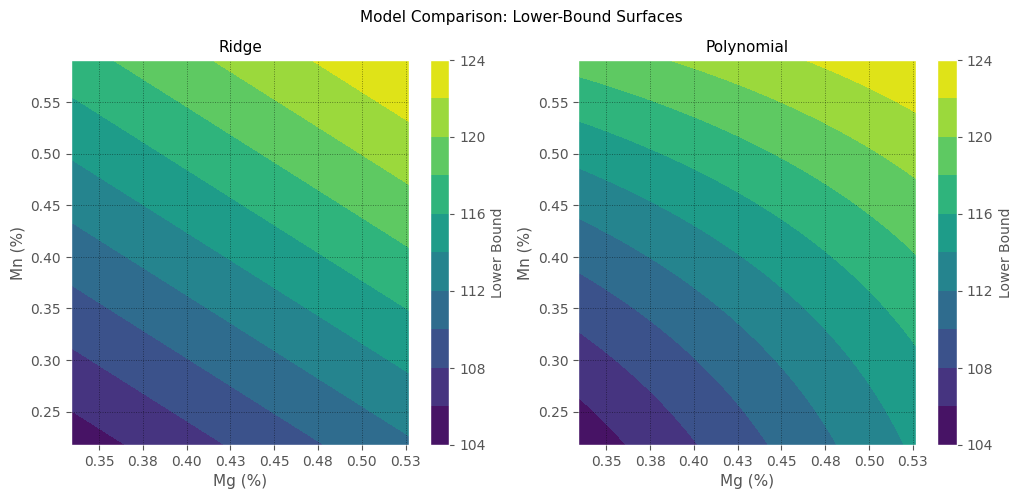

✓ Figure 9: Model comparison surfaces saved


In [13]:
# Figure 9 — Model Comparison: Lower-Bound Surfaces (Ridge vs Polynomial)
SURFACES = {'Ridge': y_lower_ridge, 'Polynomial': y_lower_poly}

fig, axes = plot_model_comparison_surfaces(
    MG, MN,
    surfaces_dict=SURFACES,
    x_label='Mg (%)',
    y_label='Mn (%)',
    levels_val=10,
    show_grid=True
)
plt.show()
print('✓ Figure 9: Model comparison surfaces saved')

### 8.2 Uncertainty Band Validation 

Before translating uncertainty into design maps, the selected margin must be verified on unseen data.
The following plot visualizes out-of-fold predictions and highlights how often observed UTS values fall within the ±q band, confirming that the chosen margin provides the intended level of conservative coverage.

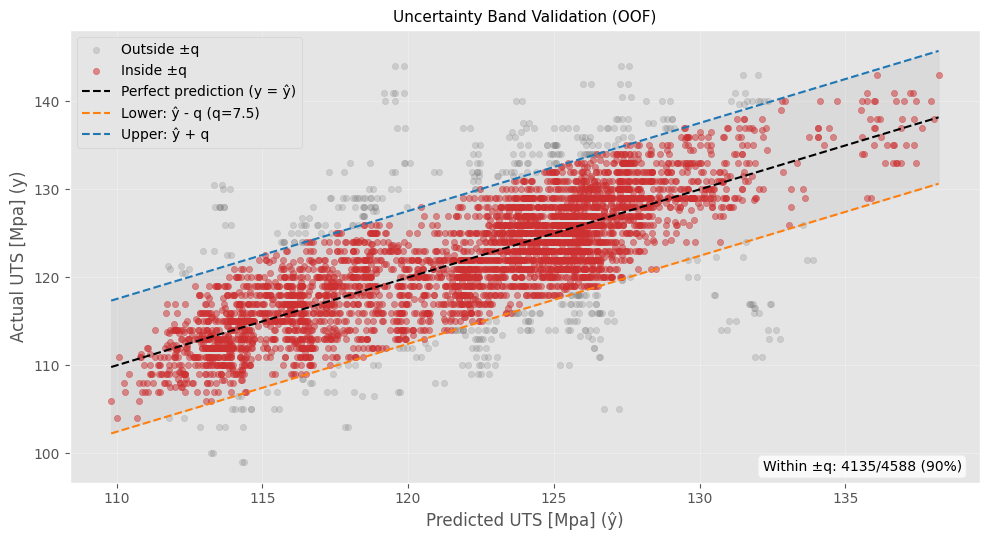

✓ Figure 10: Uncertainty band validation saved


In [14]:
# Figure 10 — Uncertainty Band Validation (OOF)
fig, ax = plot_uncertainty_band(
    oof_df,
    uncertainty_margin=q_ridge,
    show_coverage=True
)
plt.show()
print('✓ Figure 10: Uncertainty band validation saved')

### 8.3 Engineering Interpretation

**Role in engineering and metallurgy workflows**

These design maps are intended to support early- and mid-stage engineering decisions, not to replace detailed process models or final quality release criteria.

Typical use cases include:
- defining conservative chemistry windows during alloy or product design,
- screening heats or batches with known chemistry before process execution,
- supporting technical discussions between metallurgy and process engineering teams.

By exposing uncertainty explicitly, the maps allow informed decision-making even by users without deep mathematical training, while preserving a conservative, risk-aware stance.

## 9. Intended Use and Decision Boundaries

Outputs from SC05 are intended to support:
- internal standard definition,
- early-stage alloy or recipe screening,
- conservative design margin selection.

They are not intended for final product release, contractual compliance, or operational control without additional process-level validation.

## 10. Limitations and Risk Boundaries

Uncertainty estimates incorporate unmodeled sources of variability, including process history and microstructural state.

As a result, uncertainty bands should be interpreted as conservative bounds whose reduction requires additional explanatory variables rather than model tuning.

## 11. Summary and Transition

SC05 transforms chemistry-only modeling from a descriptive exercise into a decision-oriented framework.

By expressing strength behavior as uncertainty-aware design regions, this study enables risk-explicit engineering reasoning without increasing model complexity.

## Key Takeaways

- Chemistry design maps enable direct **go / no-go** screening without requiring interaction with model equations or coefficients.
- Robust regions support early-stage engineering decisions and internal standard definition, not release-grade certification.
- **Simplicity** and **stability** are first-class requirements for **engineering adoption**; model geometry matters as much as accuracy.
- Explicit uncertainty is what turns predictive models into decision tools.
- SC05 completes the transition from predictive modeling to decision deployment within the portfolio.
- The framework is intentionally conservative and extensible; additional complexity is deferred until it demonstrates clear operational value.
